# Project Group7 : Yihang Wang, Aaron Sukare

## Research Question2: How do Agentic-PRs change code?

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
#load data
pr_commit_details_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pr_commit_details.parquet")
pr_df = pd.read_parquet("hf://datasets/hao-li/AIDev/pull_request.parquet")
print("pr_commit_details shape:",pr_commit_details_df.shape)
print("pull_request_pop shape:",pr_df.shape)
print("pr_commit_details columns sample:",list(pr_commit_details_df.columns)[:10])
print("pull_request columns sample:",list(pr_df.columns)[:10])
print("agent counts sample:")
print(pr_df["agent"].value_counts().head(10))
#keep only PRs where agent is present
pr_df = pr_df[pr_df["agent"].notna()]
print("pull_request with_agent shape:",pr_df.shape)

pr_commit_details shape: (711923, 14)
pull_request_pop shape: (33596, 14)
pr_commit_details columns sample: ['sha', 'pr_id', 'author', 'committer', 'message', 'commit_stats_total', 'commit_stats_additions', 'commit_stats_deletions', 'filename', 'status']
pull_request columns sample: ['id', 'number', 'title', 'body', 'agent', 'user_id', 'user', 'state', 'created_at', 'closed_at']
agent counts sample:
agent
OpenAI_Codex    21799
Copilot          4970
Devin            4827
Cursor           1541
Claude_Code       459
Name: count, dtype: int64
pull_request with_agent shape: (33596, 14)


In [10]:
#build commit level data and aggregate per PR
need_cols = ["pr_id","sha","filename","additions","deletions","changes"]
missing_cols = [c for c in need_cols if c not in pr_commit_details_df.columns]
print("missing_cols_in_pr_commit_details:",missing_cols)
commit_cols = [c for c in need_cols if c in pr_commit_details_df.columns]
commit_files = pr_commit_details_df[commit_cols].copy()
agg_dict = {"files_touched":("filename",lambda x:x.dropna().nunique()),"num_commit_rows":("sha","nunique")}
if "additions" in commit_files.columns:
    agg_dict["total_additions"] = ("additions","sum")
if "deletions" in commit_files.columns:
    agg_dict["total_deletions"] = ("deletions","sum")
if "changes" in commit_files.columns:
    agg_dict["total_changes"] = ("changes","sum")
file_stats = commit_files.groupby("pr_id").agg(**agg_dict).reset_index()
print("file_stats shape:",file_stats.shape)
file_stats.head()

missing_cols_in_pr_commit_details: []
file_stats shape: (33580, 6)


,pr_id,files_touched,num_commit_rows,total_additions,total_deletions,total_changes
0,2756921963,15,16,848.0,344.0,1192.0
1,2757103560,16,10,517.0,262.0,779.0
2,2757124156,1,1,1.0,1.0,2.0
3,2757125491,1,1,1.0,1.0,2.0
4,2757179026,15,6,1633.0,169.0,1802.0


In [11]:
#join patch stats with PR meta
meta_cols = ["id","agent","state","created_at","merged_at","repo_id"]
meta_cols = [c for c in meta_cols if c in pr_df.columns]
pr_meta = pr_df[meta_cols].copy()
if "created_at" in pr_meta.columns:
    pr_meta["created_at"] = pd.to_datetime(pr_meta["created_at"],errors="coerce")
if "merged_at" in pr_meta.columns:
    pr_meta["merged_at"] = pd.to_datetime(pr_meta["merged_at"],errors="coerce")
pr_patch = file_stats.merge(pr_meta,left_on="pr_id",right_on="id",how="inner")
print("pr_patch shape:",pr_patch.shape)
patch_cols = [c for c in ["total_additions","total_deletions","total_changes","files_touched"] if c in pr_patch.columns]
pr_patch[patch_cols].head()

pr_patch shape: (33580, 12)


,total_additions,total_deletions,total_changes,files_touched
0,848.0,344.0,1192.0,15
1,517.0,262.0,779.0,16
2,1.0,1.0,2.0,1
3,1.0,1.0,2.0,1
4,1633.0,169.0,1802.0,15


In [12]:
#overall patch size distribution
if len(patch_cols) > 0:
    patch_desc = pr_patch[patch_cols].describe(percentiles=[0.5,0.9,0.95]).round(2)
    print("patch_size_distribution")
    print(patch_desc)
else:
    print("no patch_cols available for describe")

patch_size_distribution
       total_additions  total_deletions  total_changes  files_touched
count         33580.00         33580.00       33580.00       33580.00
mean           1286.40           686.78        1973.18          17.15
std           12554.17         10301.85       20589.14          55.09
min               0.00             0.00           0.00           0.00
50%              72.00            10.00          95.00           3.00
90%            1208.00           408.00        1844.00          30.00
95%            3658.15          1441.00        5534.90          80.00
max         1053409.00        981515.00     1964377.00        1641.00


In [13]:
#median patch stats by merge status and by agent
if "merged_at" in pr_patch.columns and len(patch_cols)>0:
    pr_patch["is_merged"] = pr_patch["merged_at"].notna()
    patch_by_merge = pr_patch.groupby("is_merged")[patch_cols].median().reset_index()
    print("median_patch_stats_by_merge_status")
    print(patch_by_merge)
if "agent" in pr_patch.columns and len(patch_cols)>0:
    sort_col = patch_cols[0]
    patch_by_agent = pr_patch.groupby("agent")[patch_cols].median().reset_index().sort_values(sort_col,ascending=False)
    print("median_patch_stats_by_agent_sample")
    print(patch_by_agent.head(20))
if "total_changes" in patch_cols:
    small_pr = pr_patch[pr_patch["total_changes"]<=20].shape[0]
    large_pr = pr_patch[pr_patch["total_changes"]>=500].shape[0]
    print("small_pr_changes<=20",small_pr)
    print("large_pr_changes>=500",large_pr)

median_patch_stats_by_merge_status
   is_merged  total_additions  total_deletions  total_changes  files_touched
0      False            123.0             16.0          160.5            4.0
1       True             60.0              8.0           79.0            3.0
median_patch_stats_by_agent_sample
          agent  total_additions  total_deletions  total_changes  \
0   Claude_Code            577.0             74.0          691.0   
2        Cursor            201.0             40.0          271.5   
1       Copilot            127.0             21.0          179.0   
3         Devin            117.5             27.0          167.0   
4  OpenAI_Codex             59.0              6.0           74.0   

   files_touched  
0            8.0  
2            4.0  
1            4.0  
3            4.0  
4            3.0  
small_pr_changes<=20 7400
large_pr_changes>=500 6909


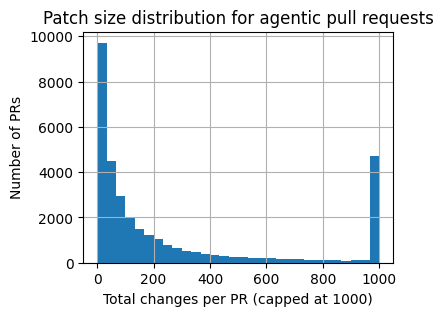

In [14]:
#histogram of total changes for agentic PRs
if "total_changes" in pr_patch.columns:
    plt.figure(figsize=(4,3))
    pr_patch["total_changes"].clip(upper=1000).hist(bins=30)
    plt.xlabel("Total changes per PR (capped at 1000)")
    plt.ylabel("Number of PRs")
    plt.title("Patch size distribution for agentic pull requests")
    plt.show()

Most the agentic pull requests changes only small amount of code but a few are very big changes.